In [25]:
# ---- Cell 1: Imports + Global Settings ----

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns  # if error: run: !pip install seaborn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ✅ Your dataset path
DATASET_DIR = r"d:\pathhole\dataset"   # contains normal / moderate / severe

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Training epochs
EPOCHS_STAGE1 = 5      # train only classifier head
EPOCHS_STAGE2 = 15     # fine-tune with more layers


In [26]:
import os
print(os.getcwd())
print(os.listdir())


d:\pathhole\dataset
['moderate', 'normal', 'severe', 'severity_final.keras', 'severity_stage1.keras', 'train.ipynb']


In [7]:
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".png", ".jpeg"))])
        print(f"{cls}: {n} images")


moderate: 215 images
normal: 352 images
severe: 254 images


In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("Class indices:", train_generator.class_indices)


Found 658 images belonging to 3 classes.
Found 163 images belonging to 3 classes.
Class indices: {'moderate': 0, 'normal': 1, 'severe': 2}


In [9]:
# ---- Cell 4: Build the MobileNetV2 model ----

def build_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # First, freeze base_model weights
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model(num_classes=len(train_generator.class_indices))
model.summary()

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7340 - loss: 0.6351 - val_accuracy: 0.8896 - val_loss: 0.3095
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8754 - loss: 0.3269 - val_accuracy: 0.8957 - val_loss: 0.2633
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9088 - loss: 0.2465 - val_accuracy: 0.9202 - val_loss: 0.2157
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9073 - loss: 0.2475 - val_accuracy: 0.9141 - val_loss: 0.2677
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9134 - loss: 0.2242 - val_accuracy: 0.9387 - val_loss: 0.1750


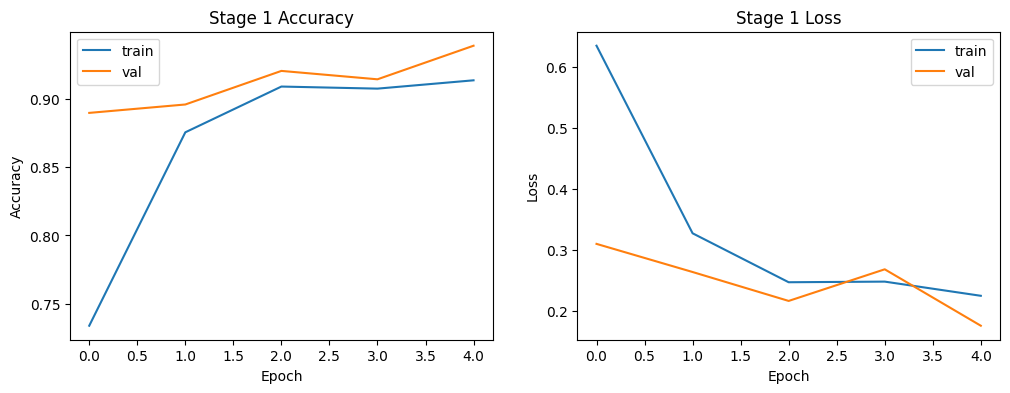

In [10]:
# ---- Cell 5: Train only top layers (Stage 1) ----

checkpoint_cb = ModelCheckpoint(
    "severity_stage1.keras", save_best_only=True, monitor="val_loss"
)
earlystop_cb = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb]
)

# Plot training curves
def plot_history(hist, title_prefix="Stage 1"):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_history(history1, "Stage 1")


Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8906 - loss: 0.3155 - val_accuracy: 0.8344 - val_loss: 0.7991
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9316 - loss: 0.1777 - val_accuracy: 0.8466 - val_loss: 0.5975
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9620 - loss: 0.1172 - val_accuracy: 0.8344 - val_loss: 0.7691
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9529 - loss: 0.1064 - val_accuracy: 0.8650 - val_loss: 0.4468
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9696 - loss: 0.0905 - val_accuracy: 0.8896 - val_loss: 0.3299
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9833 - loss: 0.0593 - val_accuracy: 0.9325 - val_loss: 0.2318
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9726 - loss: 0.0809 - val_accuracy: 0.9632 - val_loss: 0.1647
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9757 - loss: 0.0550 - val_accuracy: 0.9632 - val_loss:

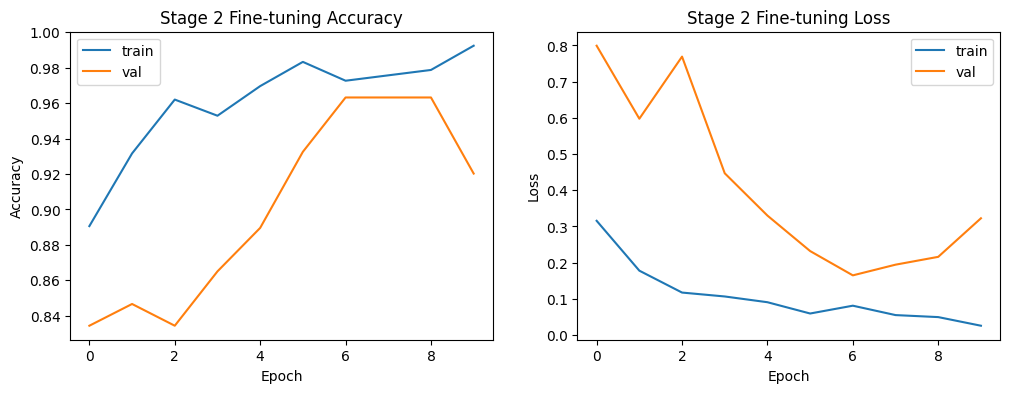

In [11]:
# ---- Cell 6: Fine-tuning Stage 2 ----

# Get MobileNetV2 base model (2nd layer in our model)
base_model = model.layers[1]
base_model.trainable = True

# Optionally keep earlier layers frozen to avoid overfitting
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(1e-4),   # smaller learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_cb2 = ModelCheckpoint(
    "severity_final.keras", save_best_only=True, monitor="val_loss"
)
earlystop_cb2 = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=val_generator,
    callbacks=[checkpoint_cb2, earlystop_cb2]
)

plot_history(history2, "Stage 2 Fine-tuning")


In [12]:
# ---- Cell 7: Evaluation ----

from tensorflow.keras.models import load_model

best_model = load_model("severity_final.keras")

val_generator.reset()
loss, acc = best_model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 918ms/step - accuracy: 0.9448 - loss: 0.1910
Validation Loss: 0.1910
Validation Accuracy: 0.9448


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 
Class order: ['moderate', 'normal', 'severe']
Confusion Matrix:
 [[42  0  1]
 [ 0 69  1]
 [ 8  1 41]]

Classification Report:
              precision    recall  f1-score   support

    moderate       0.84      0.98      0.90        43
      normal       0.99      0.99      0.99        70
      severe       0.95      0.82      0.88        50

    accuracy                           0.93       163
   macro avg       0.93      0.93      0.92       163
weighted avg       0.94      0.93      0.93       163



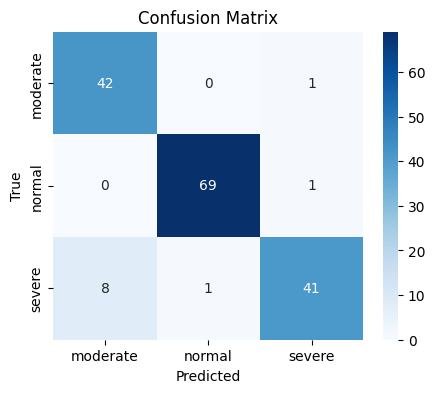

In [13]:
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = best_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_indices = val_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Class order:", class_names)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [16]:
# ---- Cell 8: Predict severity for any image (local or URL) ----

import requests
from io import BytesIO
from PIL import Image
from tensorflow.keras.utils import img_to_array   # <-- FIX ADDED

def predict_severity_any(src):
    """
    src = local path or URL
    Uses trained 3-class CNN: normal / moderate / severe
    """

    # Load image (URL or local)
    try:
        if src.startswith("http://") or src.startswith("https://"):
            resp = requests.get(src, timeout=10)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
        else:
            img = Image.open(src).convert("RGB")
    except Exception as e:
        print("Error loading image:", e)
        return

    # Preprocess
    arr = img.resize(IMG_SIZE)
    arr = img_to_array(arr)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    # Predict
    probs = best_model.predict(arr)[0]
    idx = np.argmax(probs)

    # Map index → class name
    class_indices = train_generator.class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}
    label = idx_to_class[idx]
    conf = probs[idx]

    print(f"Prediction: {label.upper()}  | Confidence: {conf:.4f}")
    print("\nAll class probabilities:")
    for cls_name, p in zip(idx_to_class.values(), probs):
        print(f"  {cls_name}: {p:.4f}")

    plt.imshow(img)
    plt.title(f"{label.upper()} ({conf:.4f})")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Prediction: MODERATE  | Confidence: 0.9999

All class probabilities:
  moderate: 0.9999
  normal: 0.0000
  severe: 0.0001


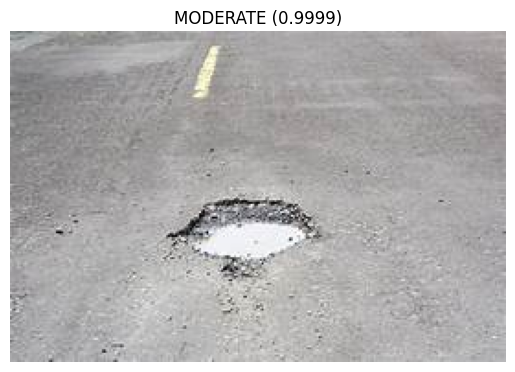

In [20]:
predict_severity_any("https://tse1.mm.bing.net/th/id/OIP.NsynqOEFfNwTsTlRWm0u-gHaE8?pid=Api&P=0&h=180")


In [21]:
# ====================================================
# FINAL SEVERITY PREDICTION MODULE  (RUN THIS CELL FIRST)
# ====================================================

# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ---- Global settings ----
IMG_SIZE = (224, 224)

# IMPORTANT: Path to your trained 3-class model
MODEL_PATH = r"d:\pathhole\dataset\severity_final.keras"

# Class names in the SAME ORDER as training
# (in your case it was: {'moderate': 0, 'normal': 1, 'severe': 2})
CLASS_NAMES = ["moderate", "normal", "severe"]

# ---- Load model ----
try:
    model = load_model(MODEL_PATH)
    print("✅ Model loaded successfully from:", MODEL_PATH)
except Exception as e:
    print("❌ ERROR loading model:", e)
    model = None


# ----------------------------------------------------
# Helper: Load image from local path or URL
# ----------------------------------------------------
def load_image_any(src):
    """
    Load an image from:
      - local path  (e.g. r'd:\\pathhole\\dataset\\moderate\\img1.jpg')
      - URL         (e.g. 'https://....jpg')
    Returns a PIL.Image object, or None on error.
    """
    try:
        if src.startswith("http://") or src.startswith("https://"):
            resp = requests.get(src, timeout=10)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
        else:
            img = Image.open(src).convert("RGB")
        return img
    except Exception as e:
        print("❌ ERROR loading image:", e)
        return None


# ----------------------------------------------------
# MAIN: Predict severity (normal / moderate / severe)
# ----------------------------------------------------
def predict_severity_any(src):
    """
    src: local image path or URL.

    Uses trained 3-class CNN to classify:
      - NORMAL
      - MODERATE
      - SEVERE
    """

    if model is None:
        print("❌ Model is not loaded. Check MODEL_PATH and rerun this cell.")
        return

    # 1) Load image
    img = load_image_any(src)
    if img is None:
        return

    # 2) Preprocess for MobileNetV2
    arr = img.resize(IMG_SIZE)
    arr = img_to_array(arr)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)  # shape (1, 224, 224, 3)

    # 3) Predict
    probs = model.predict(arr)[0]   # shape (3,)
    idx = np.argmax(probs)
    label = CLASS_NAMES[idx]
    conf = probs[idx]

    # 4) Print results
    print(f"\n🧠 Prediction: {label.upper()}  | Confidence: {conf:.4f}")
    print("Class probabilities:")
    for cls_name, p in zip(CLASS_NAMES, probs):
        print(f"  {cls_name:8s}: {p:.4f}")

    # 5) Show image with title
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"{label.upper()} ({conf:.4f})")
    plt.axis("off")
    plt.show()


print("\n✨ Prediction module ready. Use: predict_severity_any('path_or_url')")


✅ Model loaded successfully from: d:\pathhole\dataset\severity_final.keras

✨ Prediction module ready. Use: predict_severity_any('path_or_url')


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

🧠 Prediction: SEVERE  | Confidence: 1.0000
Class probabilities:
  moderate: 0.0000
  normal  : 0.0000
  severe  : 1.0000


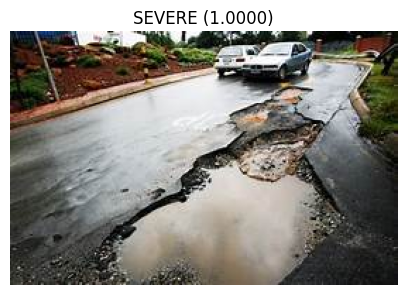

In [22]:
predict_severity_any("https://tse3.mm.bing.net/th/id/OIP.c7c8krr6A196X-Y92jfJ9QHaE2?pid=Api&P=0&h=180")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
✔ Class Names: ['moderate', 'normal', 'severe']

Confusion Matrix:
[[42  0  1]
 [ 0 67  3]
 [ 7  0 43]]


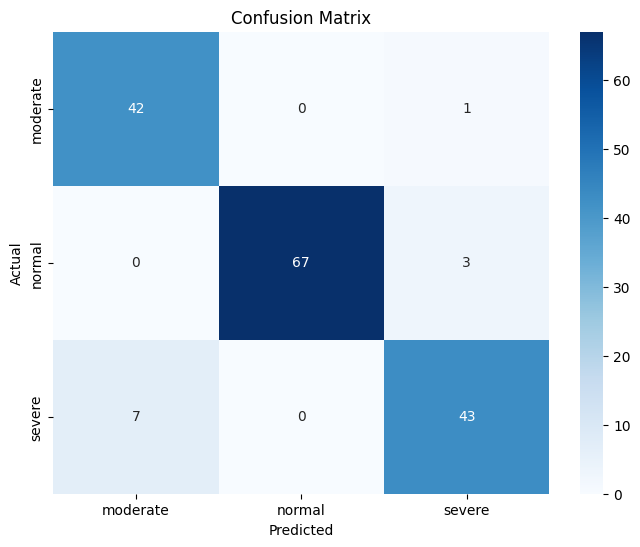


Classification Report:
              precision    recall  f1-score   support

    moderate       0.86      0.98      0.91        43
      normal       1.00      0.96      0.98        70
      severe       0.91      0.86      0.89        50

    accuracy                           0.93       163
   macro avg       0.92      0.93      0.93       163
weighted avg       0.94      0.93      0.93       163



In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure validation generator is reset
val_generator.reset()

# Predict on all validation data
y_true = []
y_pred = []

for i in range(len(val_generator)):
    x_batch, y_batch = next(val_generator)
    preds = best_model.predict(x_batch)

    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

class_names = list(val_generator.class_indices.keys())

print("✔ Class Names:", class_names)
print("\nConfusion Matrix:")
print(cm)

# Plot Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


In [24]:
acc = np.mean(y_true == y_pred)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")



🔥 Model Accuracy: 93.25%


In [40]:
# ---- Cell 1: Imports + Global Settings ----

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns  # if error: run: !pip install seaborn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ✅ Your dataset path
DATASET_DIR = r"d:\pathhole\dataset"   # contains normal / moderate / severe

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Training epochs
EPOCHS_STAGE1 = 5      # train only classifier head
EPOCHS_STAGE2 = 15     # fine-tune with more layers


In [41]:
# ---- Cell 2: Check dataset structure and counts ----

print("Dataset directory:", DATASET_DIR)
print("Subfolders (classes):", os.listdir(DATASET_DIR))

for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        print(f"{cls}: {n} images")


Dataset directory: d:\pathhole\dataset
Subfolders (classes): ['moderate', 'normal', 'severe', 'severity_final.keras', 'severity_stage1.keras', 'train.ipynb']
moderate: 214 images
normal: 352 images
severe: 219 images


In [42]:
# ---- Cell 3: Train/Validation ImageDataGenerator ----

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("Class indices:", train_generator.class_indices)  # e.g. {'moderate':0, 'normal':1, 'severe':2}
num_classes = len(train_generator.class_indices)


Found 630 images belonging to 3 classes.
Found 155 images belonging to 3 classes.
Class indices: {'moderate': 0, 'normal': 1, 'severe': 2}


In [43]:
# ---- Cell 4: Compute class weights (for unbalanced data) ----

y_train = train_generator.classes  # labels for training images
classes = np.unique(y_train)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights_arr))
print("Class weights:", class_weights)

# For reference: index → class name
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
print("Index to class:", idx_to_class)


Class weights: {np.int32(0): np.float64(1.2209302325581395), np.int32(1): np.float64(0.7446808510638298), np.int32(2): np.float64(1.1931818181818181)}
Index to class: {0: 'moderate', 1: 'normal', 2: 'severe'}


In [ ]:
# ---- Cell 5: Build MobileNetV2 model ----

def build_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Stage 1: we will freeze this first
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model(num_classes=num_classes)
model.summary()

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
k

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7127 - loss: 0.6813 - val_accuracy: 0.8581 - val_loss: 0.3203
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8762 - loss: 0.3545 - val_accuracy: 0.9226 - val_loss: 0.1948
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9000 - loss: 0.2580 - val_accuracy: 0.8968 - val_loss: 0.2610
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9143 - loss: 0.2514 - val_accuracy: 0.9355 - val_loss: 0.1930
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9302 - loss: 0.2219 - val_accuracy: 0.9226 - val_loss: 0.1687


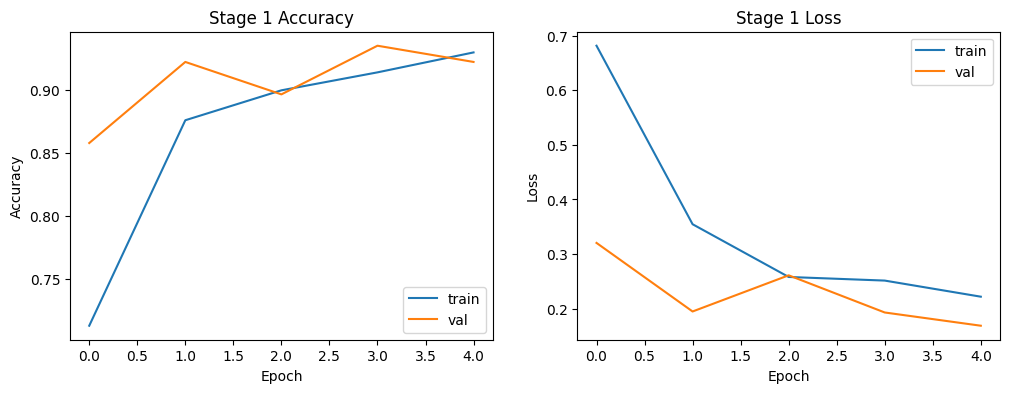

In [45]:
# ---- Cell 6: Train classifier head (Stage 1) ----

checkpoint_cb = ModelCheckpoint(
    "severity_stage1.keras",
    save_best_only=True,
    monitor="val_loss"
)
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    class_weight=class_weights
)

def plot_history(hist, title_prefix="Stage"):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_history(history1, "Stage 1")


Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9032 - loss: 0.2922 - val_accuracy: 0.8323 - val_loss: 0.4739
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9444 - loss: 0.1864 - val_accuracy: 0.8323 - val_loss: 0.4488
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9286 - loss: 0.1942 - val_accuracy: 0.9032 - val_loss: 0.2894
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9476 - loss: 0.1331 - val_accuracy: 0.8581 - val_loss: 0.4798
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9587 - loss: 0.1095 - val_accuracy: 0.8258 - val_loss: 0.7198
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9794 - loss: 0.0631 - val_accuracy: 0.8387 - val_loss: 0.5592
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9889 - loss: 0.0499 - val_accuracy: 0.8194 - val_loss: 0.8030
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9841 - loss: 0.0555 - val_accuracy: 0.8839 - val_loss:

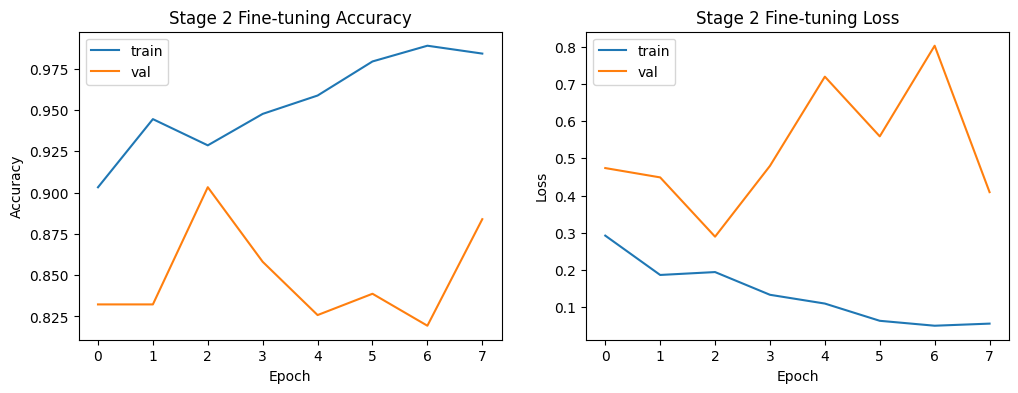

In [46]:
# ---- Cell 7: Fine-tuning (Stage 2) ----

# Get base MobileNetV2 from our model (2nd layer)
base_model = model.layers[1]
base_model.trainable = True

# Freeze only first 60 layers → more layers are trainable now
for layer in base_model.layers[:60]:
    layer.trainable = False

for layer in base_model.layers[60:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-4),  # smaller learning rate for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_cb2 = ModelCheckpoint(
    "severity_final.keras",   # ✅ final model saved here
    save_best_only=True,
    monitor="val_loss"
)
earlystop_cb2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=val_generator,
    callbacks=[checkpoint_cb2, earlystop_cb2],
    class_weight=class_weights
)

plot_history(history2, "Stage 2 Fine-tuning")


Loaded best model: severity_final.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 890ms/step - accuracy: 0.9097 - loss: 0.1753

Validation Loss: 0.1753
Validation Accuracy: 90.97%
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Class names: ['moderate', 'normal', 'severe']
Confusion Matrix:
 [[41  0  1]
 [ 1 68  1]
 [ 5  0 38]]


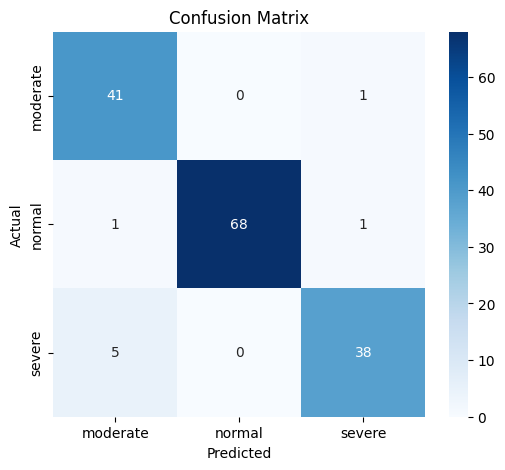


Classification Report:
              precision    recall  f1-score   support

    moderate       0.87      0.98      0.92        42
      normal       1.00      0.97      0.99        70
      severe       0.95      0.88      0.92        43

    accuracy                           0.95       155
   macro avg       0.94      0.94      0.94       155
weighted avg       0.95      0.95      0.95       155


🔥 Overall model accuracy (from confusion matrix): 94.84%


In [47]:
# ---- Cell 8: Evaluation (Accuracy + Confusion Matrix + Report) ----

from tensorflow.keras.models import load_model

best_model = load_model("severity_final.keras")
print("Loaded best model: severity_final.keras")

# Evaluate on validation generator
val_generator.reset()
loss, acc = best_model.evaluate(val_generator)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc * 100:.2f}%")

# Predictions for confusion matrix
val_generator.reset()
y_true = []
y_pred = []

for i in range(len(val_generator)):
    x_batch, y_batch = next(val_generator)
    preds = best_model.predict(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

# Class names in correct order
class_names = list(val_generator.class_indices.keys())
print("\nClass names:", class_names)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

overall_acc = np.mean(y_true == y_pred)
print(f"\n🔥 Overall model accuracy (from confusion matrix): {overall_acc * 100:.2f}%")


In [48]:
# ---- Cell 9: Predict for ANY image (local or URL) ----

import requests
from io import BytesIO
from PIL import Image
from tensorflow.keras.utils import img_to_array

MODEL_PATH = "severity_final.keras"
best_model = load_model(MODEL_PATH)
print("Prediction model loaded:", MODEL_PATH)

def load_image_any(src):
    try:
        if src.startswith("http://") or src.startswith("https://"):
            resp = requests.get(src, timeout=10)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
        else:
            img = Image.open(src).convert("RGB")
        return img
    except Exception as e:
        print("Error loading image:", e)
        return None

def predict_severity_any(src):
    """
    src: local path or URL
    Output: NORMAL / MODERATE / SEVERE
    """
    img = load_image_any(src)
    if img is None:
        return

    arr = img.resize(IMG_SIZE)
    arr = img_to_array(arr)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    probs = best_model.predict(arr)[0]
    idx = np.argmax(probs)

    # map index -> class name
    class_indices = train_generator.class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}
    label = idx_to_class[idx]
    conf = probs[idx]

    print(f"\nPrediction: {label.upper()}  | Confidence: {conf:.4f}")
    print("Class probabilities:")
    for i, p in enumerate(probs):
        print(f"  {idx_to_class[i]}: {p:.4f}")

    plt.imshow(img)
    plt.title(f"{label.upper()} ({conf:.4f})")
    plt.axis("off")
    plt.show()


Prediction model loaded: severity_final.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Prediction: SEVERE  | Confidence: 0.9769
Class probabilities:
  moderate: 0.0224
  normal: 0.0007
  severe: 0.9769


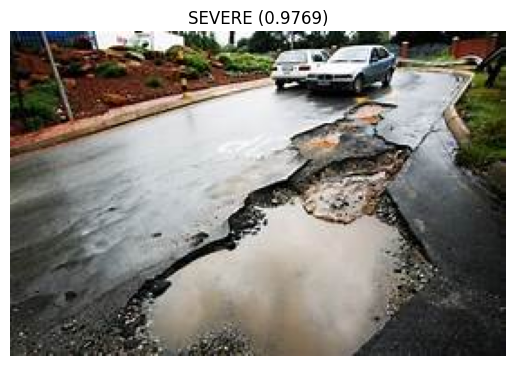

In [49]:


# Chrome image
predict_severity_any("https://tse3.mm.bing.net/th/id/OIP.c7c8krr6A196X-Y92jfJ9QHaE2?pid=Api&P=0&h=180")


In [57]:
overall_accuracy = np.mean(y_true == y_pred)
print(f"\n🔥 OVERALL MODEL ACCURACY: {overall_accuracy * 100:.2f}%")



🔥 OVERALL MODEL ACCURACY: 92.90%


In [52]:
# ---- Per-Class Accuracy ----
import numpy as np

class_names = list(val_generator.class_indices.keys())
num_classes = len(class_names)

correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

for i in range(len(y_true)):
    label = y_true[i]
    pred = y_pred[i]

    total_per_class[label] += 1
    if label == pred:
        correct_per_class[label] += 1

print("\n📌 PER-CLASS ACCURACY")
for idx, cls in enumerate(class_names):
    acc_cls = (correct_per_class[idx] / total_per_class[idx]) * 100
    print(f"  {cls.upper():10s} : {acc_cls:.2f}%")



📌 PER-CLASS ACCURACY
  MODERATE   : 97.62%
  NORMAL     : 97.14%
  SEVERE     : 81.40%


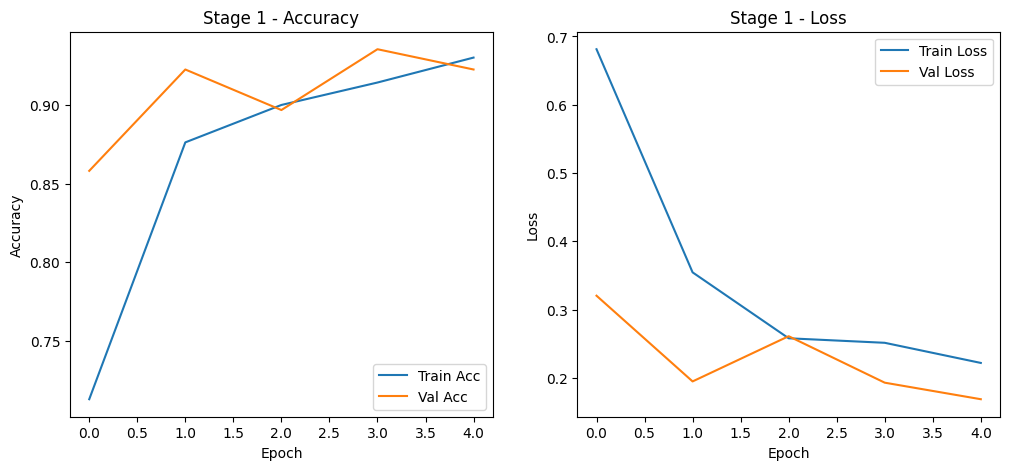

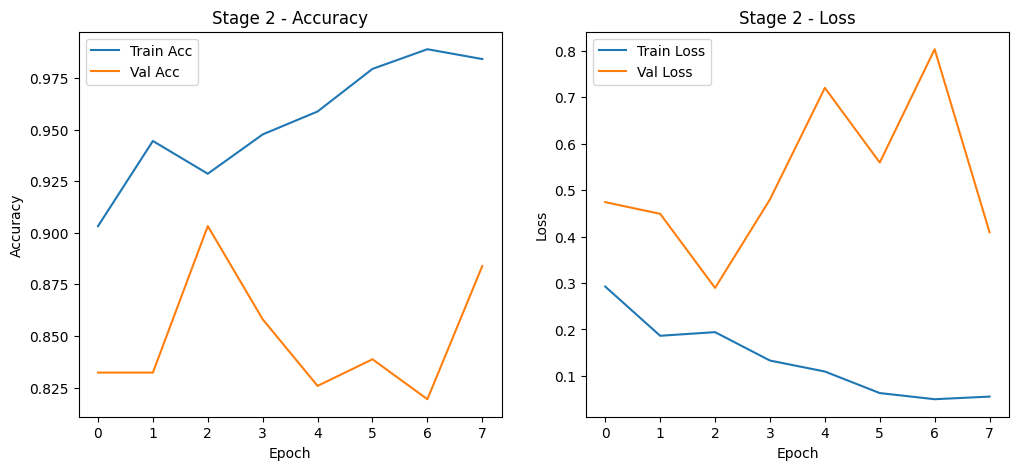

In [53]:
# ---- Training Graphs ----

def plot_history(history, title="Training Curve"):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Call this for stage 1 and stage 2:
plot_history(history1, "Stage 1")
plot_history(history2, "Stage 2")


In [54]:
# ---- Misclassification Summary ----

print("\n🔍 MISCLASSIFICATION DETAILS:")
for i in range(num_classes):
    for j in range(num_classes):
        if i != j:
            print(f"{class_names[i]} → {class_names[j]} : {cm[i][j]} times")



🔍 MISCLASSIFICATION DETAILS:
moderate → normal : 0 times
moderate → severe : 1 times
normal → moderate : 2 times
normal → severe : 0 times
severe → moderate : 8 times
severe → normal : 0 times


In [59]:
# Save the final model explicitly (optional but good)
from tensorflow.keras.models import load_model

# if 'model' is already the trained model:
model.save("severity_final.keras")
print("✅ Final model saved as severity_final.keras")


✅ Final model saved as severity_final.keras
